LINK ACCESS TO VIDEO:  https://drive.google.com/file/d/1jJaGMKSWaft9td3GtKXpMhVFZMBST9jX/view?usp=sharing

IMPORT LIBRARIES

Libraries Imported In order to analyze the dataset's structure, we first import necessary Python packages. This entails finding missing values, verifying data types, and comprehending the dataset's original composition.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.cluster import DBSCAN

sns.set(style="whitegrid")

 Load dataset

In [47]:
Alex_CA1_ML = pd.read_csv("Foodpanda Analysis Dataset.csv")

We examine the dataset and any missing values in an exploratory manner. This offers summary statistics for every characteristic and aids in the identification of null values and any outliers.

In [48]:
Alex_CA1_ML.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


Prints a brief summary that includes each column's data type and the number of non-null entries.

In [49]:
Alex_CA1_ML.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

Describe the numeric columns in the DataFrame

In [50]:
Alex_CA1_ML.describe()

,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2.991667,800.524880,25.304667,250.173667,2.996833
std,1.414778,404.855029,14.358930,144.608478,1.406113
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000


The code modifies the dataset missing value markers such as "?" "nan", "Na", "UnKnown", and spaces in the DataFrame.

In [51]:
Alex_CA1_ML.replace(["?", "nan", "Na", "UnKnown", " "], np.nan, inplace=True)

 Strip column names, drop duplicates

In [52]:
Alex_CA1_ML.columns = Alex_CA1_ML.columns.str.strip()

In [53]:
Alex_CA1_ML = Alex_CA1_ML.drop_duplicates()

### Part 2

Identify numerical and categorical columns

In [54]:
num_cols = Alex_CA1_ML.select_dtypes(include=["int64", "float64"]).columns
cat_cols = Alex_CA1_ML.select_dtypes(include=["object"]).columns

Fill missing values

In [55]:
Alex_CA1_ML[num_cols] = Alex_CA1_ML[num_cols].fillna(Alex_CA1_ML[num_cols].median())
for col in cat_cols:
    Alex_CA1_ML[col] = Alex_CA1_ML[col].fillna(Alex_CA1_ML[col].mode()[0])

Feature Selection for Clustering

In [56]:
cluster_features = ["quantity", "price", "order_frequency", "loyalty_points", "rating"]
X = Alex_CA1_ML[cluster_features].copy()

Standardization, is required to ensure all features contribute equally

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Evaluating Optimal Number of Clusters and Comparing Clustering Performance

Silhouette Score: Measures cohesion and separation

Davies–Bouldin Index (DBI): Measures cluster compactness and separation 

In [58]:
range_k = range(2, 10)
sil_scores = []
dbi_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_scores.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

Visualizing Cluster Quality

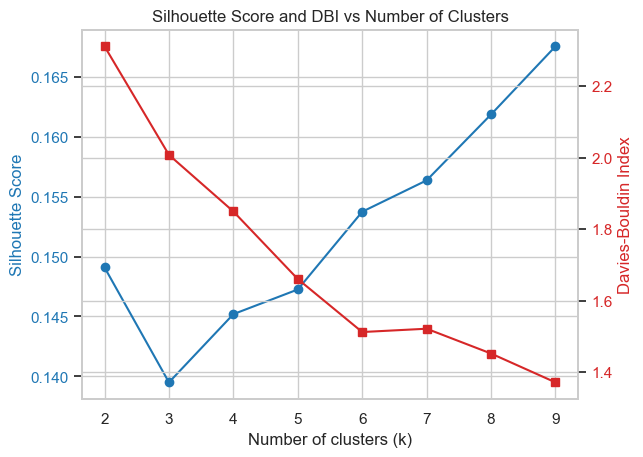

([np.float64(0.14909678121358522),
  np.float64(0.13949503426999862),
  np.float64(0.14519487569555295),
  np.float64(0.14725618274584198),
  np.float64(0.1537510460586705),
  np.float64(0.15637098002134867),
  np.float64(0.16187641019631135),
  np.float64(0.16756521835608587)],
 [np.float64(2.3108696308219807),
  np.float64(2.0074033601468253),
  np.float64(1.849166366481905),
  np.float64(1.6602376173912448),
  np.float64(1.5120888658325413),
  np.float64(1.521342130082186),
  np.float64(1.452001527615189),
  np.float64(1.371325617233739)])

In [59]:
fig, ax1 = plt.subplots()

color1 = "tab:blue"
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Silhouette Score", color=color1)
ax1.plot(range_k, sil_scores, marker="o", color=color1, label="Silhouette")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Davies-Bouldin Index", color=color2)
ax2.plot(range_k, dbi_scores, marker="s", color=color2, label="DBI")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Silhouette Score and DBI vs Number of Clusters")
plt.show()

sil_scores, dbi_scores

#  (Rink, 2022)

Plot evaluation, Comparing Clustering Performance

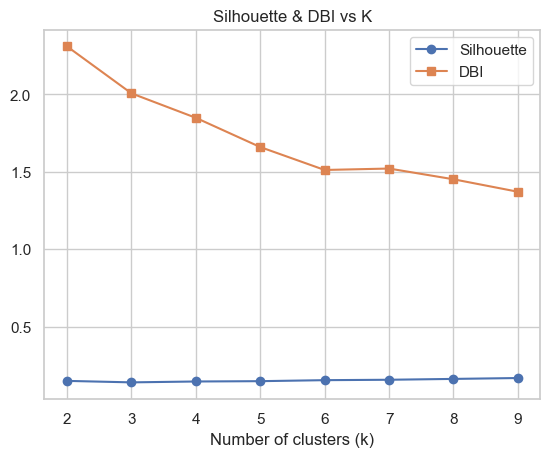

In [60]:
plt.figure()
plt.plot(range_k, sil_scores, marker='o', label='Silhouette')
plt.plot(range_k, dbi_scores, marker='s', label='DBI')
plt.xlabel("Number of clusters (k)")
plt.legend()
plt.title("Silhouette & DBI vs K")
plt.show()

Select the best K and apply K-means

In [61]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
Alex_CA1_ML["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

Apply agglomerative clustering

In [62]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
Alex_CA1_ML["cluster_agg"] = agg.fit_predict(X_scaled)

Compare clustering performance

In [63]:
sil_kmeans = silhouette_score(X_scaled, Alex_CA1_ML["cluster_kmeans"])
dbi_kmeans = davies_bouldin_score(X_scaled, Alex_CA1_ML["cluster_kmeans"])

sil_agg = silhouette_score(X_scaled, Alex_CA1_ML["cluster_agg"])
dbi_agg = davies_bouldin_score(X_scaled, Alex_CA1_ML["cluster_agg"])

print("KMeans  Silhouette:", sil_kmeans, "DBI:", dbi_kmeans)
print("Agglomerative Silhouette:", sil_agg, "DBI:", dbi_agg)

# (scikit-learn, 2019)

KMeans  Silhouette: 0.14519487569555295 DBI: 1.849166366481905
Agglomerative Silhouette: 0.07954103792657435 DBI: 2.271205463726999


Implementing PCA Projection, visualization of Kmeans clusters and plot PCA clusters

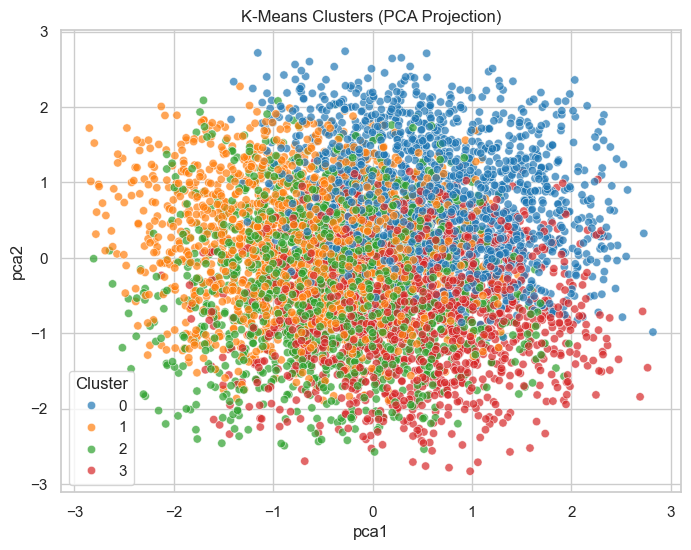

In [64]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Alex_CA1_ML["pca1"] = X_pca[:, 0]
Alex_CA1_ML["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=Alex_CA1_ML,
    x="pca1",
    y="pca2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.7
)
plt.title("K-Means Clusters (PCA Projection)")
plt.legend(title="Cluster")
plt.show()

# (Barragan, 2024)

Cluster Profiles between segments, enabling actionable insights

In [65]:
cluster_profile = Alex_CA1_ML.groupby("cluster_kmeans")[cluster_features].mean()
print(cluster_profile)

                quantity       price  order_frequency  loyalty_points  \
cluster_kmeans                                                          
0               1.719276  803.192296        20.815653      132.674644   
1               4.343124  803.288538        28.929907      139.085447   
2               2.594313  796.520069        39.472261      359.965326   
3               3.332232  798.880991        12.807794      375.500000   

                  rating  
cluster_kmeans            
0               3.120957  
1               2.813752  
2               3.040915  
3               3.009247  


Plot cluster profiles

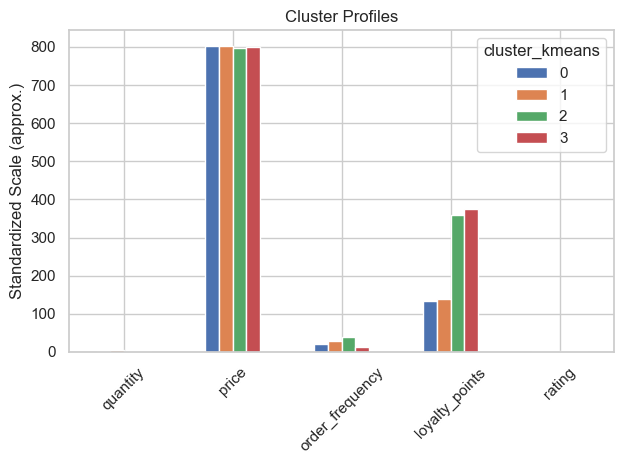

In [66]:
cluster_profile.T.plot(kind="bar")
plt.title("Cluster Profiles")
plt.ylabel("Standardized Scale (approx.)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# (Rink, 2022)

 ### Part 3 TIME SERIES ANALYSIS 

Create revenue and convert date

In [67]:
Alex_CA1_ML["order_date"] = pd.to_datetime(Alex_CA1_ML["order_date"], errors="coerce")
Alex_CA1_ML["revenue"] = Alex_CA1_ML["price"] * Alex_CA1_ML["quantity"]

Drop invalid dates

In [68]:
Alex_CA1_ML = Alex_CA1_ML.dropna(subset=["order_date"])

Aggregate daily revenue

In [69]:
daily_rev = Alex_CA1_ML.groupby("order_date")["revenue"].sum().sort_index()

Frequency to avoid warnings

In [70]:
daily_rev = daily_rev.asfreq('D')

Visualization of Daily Revenue Over Time

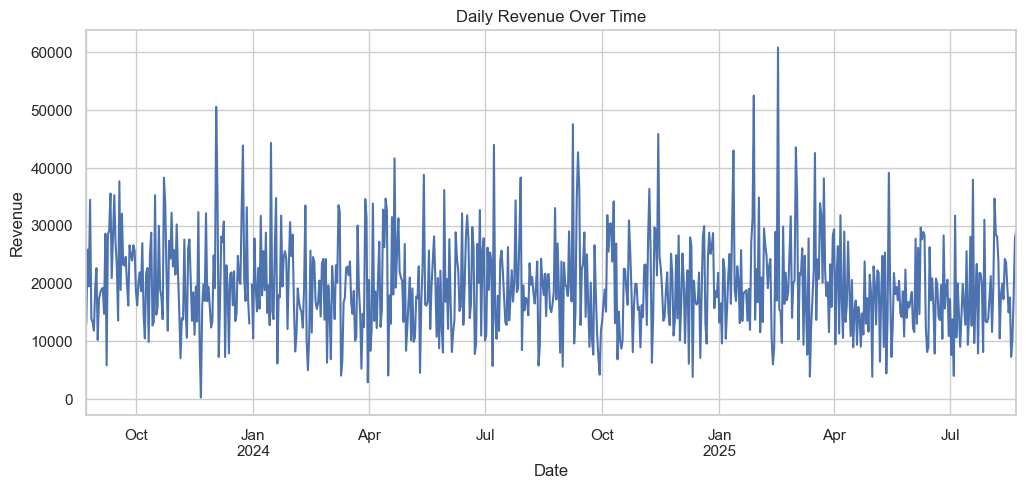

In [71]:
plt.figure(figsize=(12, 5))
daily_rev.plot()
plt.title("Daily Revenue Over Time")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.show()



Print the critical value of ADF statistics stationary test

In [72]:
adf_result = adfuller(daily_rev.dropna())
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print("Critical Value (%s): %.3f" % (key, value))

ADF Statistic: -26.40496180690523
p-value: 0.0
Critical Value (1%): -3.439
Critical Value (5%): -2.866
Critical Value (10%): -2.569


Differenced betwen Daily Revenue

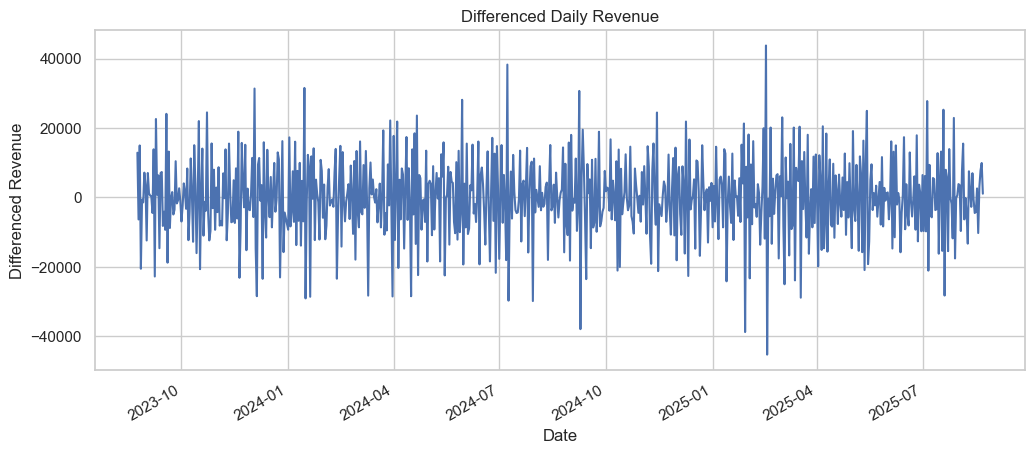

In [73]:
daily_rev_diff = daily_rev.diff().dropna()

plt.figure(figsize=(12, 5))
daily_rev_diff.plot()
plt.title("Differenced Daily Revenue")
plt.ylabel("Differenced Revenue")
plt.xlabel("Date")
plt.show()

Print the ADF results 

In [74]:
adf_result = adfuller(daily_rev.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -26.40496180690523
p-value: 0.0


Visualization of ACF and PACF

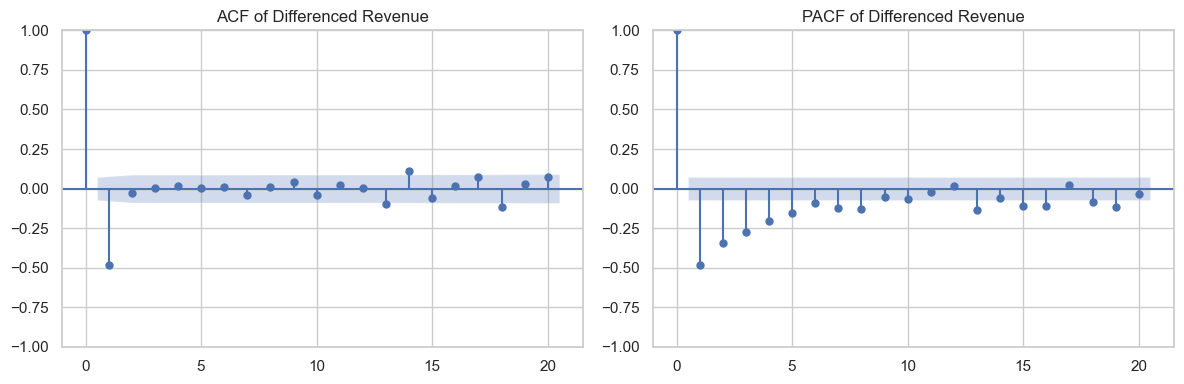

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(daily_rev_diff, ax=axes[0], lags=20)
plot_pacf(daily_rev_diff, ax=axes[1], lags=20, method="ywm")
axes[0].set_title("ACF of Differenced Revenue")
axes[1].set_title("PACF of Differenced Revenue")
plt.tight_layout()
plt.show()

Train test split

In [76]:
split_idx = int(len(daily_rev) * 0.8)

train = daily_rev[:split_idx]
test = daily_rev[split_idx:]

Ensure frequency

In [77]:
train = train.asfreq('D')
test = test.asfreq('D')

 Fit ARIMA MODEL Since data is stationary d = 0

In [78]:
model = ARIMA(train, order=(1, 0, 1))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                  584
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6098.569
Date:                Sun, 19 Apr 2026   AIC                          12205.137
Time:                        23:15:21   BIC                          12222.617
Sample:                    08-23-2023   HQIC                         12211.950
                         - 03-28-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.011e+04    368.498     54.562      0.000    1.94e+04    2.08e+04
ar.L1         -0.2362      1.027     -0.230      0.818      -2.248       1.776
ma.L1          0.2727      1.020      0.267      0.7

ARIMA Forecasting and Plot forecast

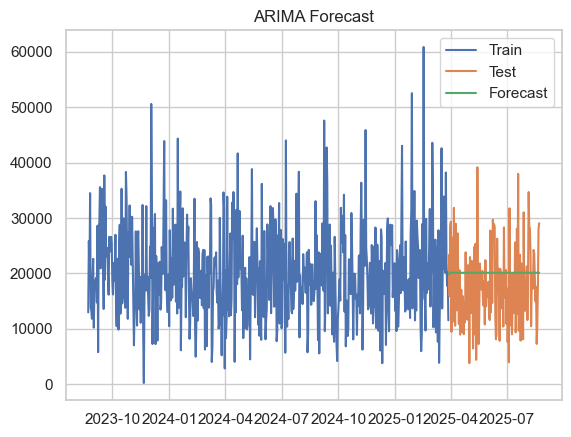

In [79]:
forecast = results.forecast(steps=len(test))

plt.figure()
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

# (GeeksforGeeks, 2024)

print the results of MAE and RMSE

In [80]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6162.612798579896
RMSE: 7463.69451800553


Verify Weekly Seasonality by ploting the results

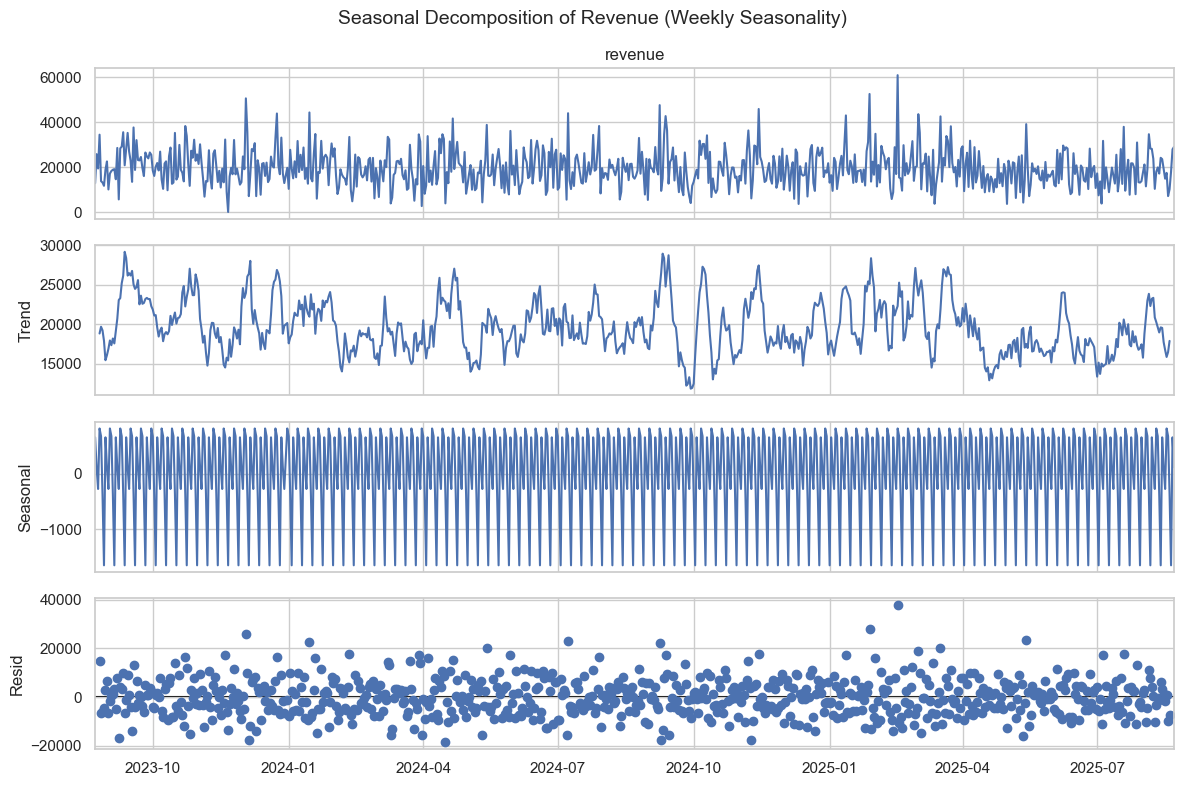

In [81]:
rev_series = daily_rev.dropna()

decomp = seasonal_decompose(rev_series, model="additive", period=7)

fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal Decomposition of Revenue (Weekly Seasonality)", fontsize=14)

plt.tight_layout()
plt.show()

# (GeeksforGeeks, 2024)

Fit SARIMA Model with weekly seasonality

In [82]:
sarima_model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),  
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit()
print(sarima_results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           revenue   No. Observations:                  584
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -6027.385
Date:                           Sun, 19 Apr 2026   AIC                          12064.770
Time:                                   23:15:24   BIC                          12086.542
Sample:                               08-23-2023   HQIC                         12073.261
                                    - 03-28-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8913      0.024     37.834      0.000       0.845       0.937
ma.L1         -0.8809      0.030    -29.154

Visualization of SAMIRA forecast vs actual 

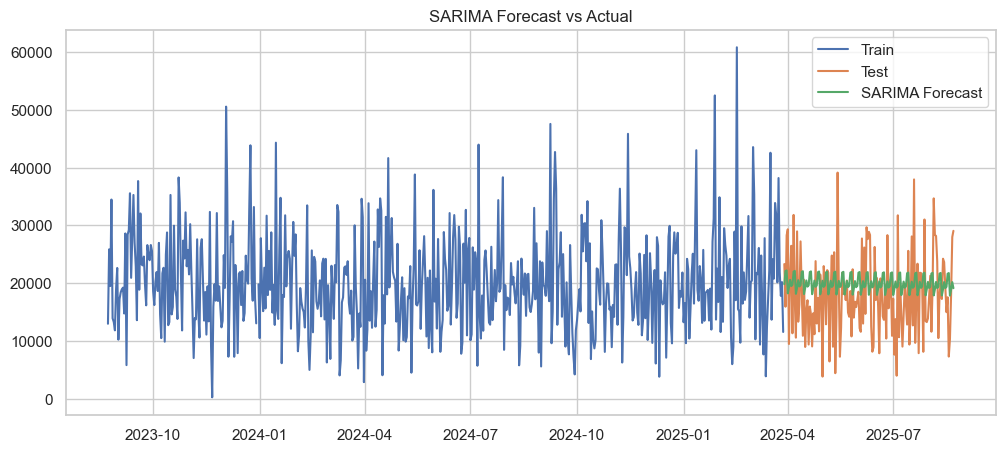

In [83]:
sarima_forecast = sarima_results.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()


#  (Github.io, 2026)

SARIMA Error Metrics

In [84]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 6307.977882668431
SARIMA RMSE: 7593.046732249478


We are beginning the clustering plocess 

In [85]:
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

Alex_CA1_ML["cluster_dbscan"] = dbscan_labels

print("DBSCAN unique labels:", np.unique(dbscan_labels))

DBSCAN unique labels: [-1  0]


DBSCAN Silhouette Score

In [86]:
valid = dbscan_labels != -1

if len(np.unique(dbscan_labels[valid])) > 1:
    sil_dbscan = silhouette_score(X_scaled[valid], dbscan_labels[valid])
    print("DBSCAN Silhouette Score:", sil_dbscan)
else:
    print("DBSCAN did not form valid clusters for Silhouette scoring.")

DBSCAN did not form valid clusters for Silhouette scoring.


DBSCAN PCA Plot

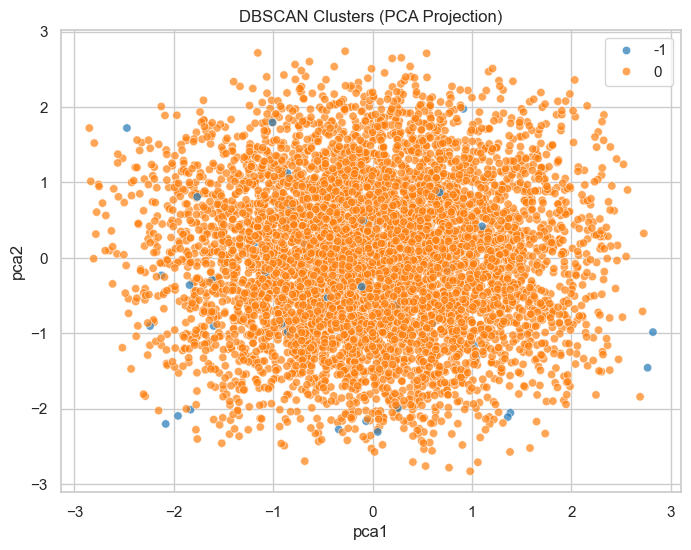

In [87]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=Alex_CA1_ML["pca1"],
    y=Alex_CA1_ML["pca2"],
    hue=dbscan_labels,
    palette="tab10",
    alpha=0.7
)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.show()

# (GeeksforGeeks, 2019)

Gaussian Mixture Models (GMM) and fit GMM

In [88]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

Alex_CA1_ML["cluster_gmm"] = gmm_labels

GMM Evaluation of Silhouette and DBI

In [89]:
sil_gmm = silhouette_score(X_scaled, gmm_labels)
dbi_gmm = davies_bouldin_score(X_scaled, gmm_labels)

print("GMM Silhouette:", sil_gmm)
print("GMM DBI:", dbi_gmm)

# (Oneoffcoder.com, 2019)

GMM Silhouette: 0.13406191987857655
GMM DBI: 2.0077138113419517


GMM PCA Plot

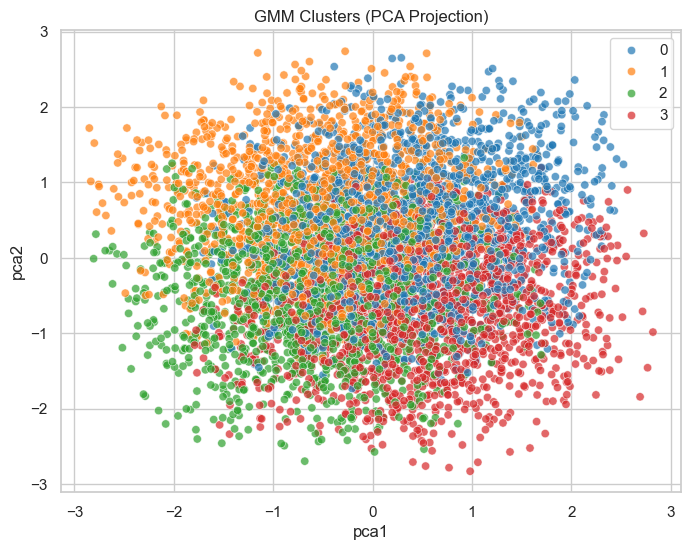

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=Alex_CA1_ML["pca1"],
    y=Alex_CA1_ML["pca2"],
    hue=gmm_labels,
    palette="tab10",
    alpha=0.7
)
plt.title("GMM Clusters (PCA Projection)")
plt.show()

# (GeeksforGeeks, 2018)

Rink, K. (2022). Best Practices for Visualizing Your Cluster Results | Towards Data Science. [online] Towards Data Science. Available at: 

https://towardsdatascience.com/best-practices-for-visualizing-your-cluster-results-20a3baac7426/.

In-text citation: (Rink, 2022)

scikit-learn (2019). Selecting the number of clusters with silhouette analysis on KMeans clustering — scikit-learn 0.21.2 documentation. [online] Scikit-learn.org. Available at: 

https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html. 

In-text citation: (scikit-learn, 2019)

Barragan, A.C. (2024). Interpreting and Validating Clustering Results with K-Means. [online] Medium. Available at: 

https://medium.com/@a.cervantes2012/interpreting-and-validating-clustering-results-with-k-means-e98227183a4d.

In-text citation: (Barragan, 2024)

Rink, K. (2022). Best Practices for Visualizing Your Cluster Results | Towards Data Science. [online] Towards Data Science. Available at: 

https://towardsdatascience.com/best-practices-for-visualizing-your-cluster-results-20a3baac7426/.

In-text citation: (Rink, 2022)

GeeksforGeeks (2024). Time Series Analysis and Forecasting. [online] GeeksforGeeks. Available at:

https://www.geeksforgeeks.org/machine-learning/time-series-analysis-and-forecasting/.

In-text citation: (GeeksforGeeks, 2024)

GeeksforGeeks (2024). Seasonal Adjustment and Differencing in Time Series. [online] GeeksforGeeks. Available at:

https://www.geeksforgeeks.org/machine-learning/seasonal-adjustment-and-differencing-in-time-series/.

In-text citation: (GeeksforGeeks, 2024)

Github.io. (2026). Blocked. [online] Available at: 

https://diogoribeiro7.github.io/time%20series/forecasting/data%20science/time_series_forecasting_sarima_seasonal_arima_explained/.

In-text citation: (Github.io, 2026)

GeeksforGeeks (2019). DBSCAN Clustering in ML Density based clustering. [online] GeeksforGeeks. Available at:

https://www.geeksforgeeks.org/machine-learning/dbscan-clustering-in-ml-density-based-clustering/.

In-text citation: (GeeksforGeeks, 2019)

Oneoffcoder.com. (2019). 5. Gaussian Mixture Models — Data Science Topics 0.0.1 documentation. [online] Available at: 

https://datascience.oneoffcoder.com/gmm.html.

In-text citation: (Oneoffcoder.com, 2019)

GeeksforGeeks (2018). Gaussian Mixture Model. [online] GeeksforGeeks. Available at:

https://www.geeksforgeeks.org/machine-learning/gaussian-mixture-model/.